# **Titanic Dataset**
https://www.kaggle.com/c/titanic/data


¿Para que nos sirve cada uno de los imports que hacemos?

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

¿Qué hace el siguiente código?

In [ ]:
df = pd.read_csv('titanic_train.csv')

# **Procesado de los datos**

Recordemos primero los **problemas** con los que nos podemos encontrar en una base de datos:


1.   Valores Nan
2.   Valores categóricos

En el ejercicio que se presenta a continuación será necesario enfrentarse a estas situaciones para poder pasar los datos correctos al algoritmo.
¿Cuáles son los distintos métodos que hemos trabajado para poder solventar estas situaciones?



## ¿Con que tipo de información vamos a trabajar?

A partir de la información subministrada por ***df.info()***; ¿Qué variables deben ser modificadas? ¿Porque razón? ¿ Qué métodos podemos emplear?



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         890 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,NaN,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# ¿Cuántas filas tiene nuestra base de datos?
df.shape[0]

891

## Transformaciones

### Datos categóricos

**SEXO**

In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female':1})

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,NaN,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


**TICKET**
Para transformar también debemos comprender los datos con los que trabajamos.

In [ ]:
df['Ticket'].value_counts()

,count
Ticket,
347082,7
CA. 2343,7
1601,7
3101295,6
CA 2144,6
...,...
9234,1
19988,1
2693,1


In [ ]:
df['Ticket'] = df['Ticket'].map(lambda k: k[0])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,P,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,S,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,1,NaN,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,3,8.0500,NaN,S


¿Que hace la siguiente función?¿Para qué nos puede servir?

In [ ]:
def encode_label(df):
    return df.astype('category').cat.codes

In [ ]:
df['Ticket'].value_counts()

,count
Ticket,
3,301
2,183
1,146
P,65
S,65
C,47
A,29
W,13
4,10


In [ ]:
df['Ticket'] = df['Ticket'].replace(['A','W','F','L','5','6','7','8','9'], '4')
df['Ticket'].value_counts()

,count
Ticket,
3,301
2,183
1,146
4,84
P,65
S,65
C,47


In [ ]:
df['Ticket'] = encode_label(df['Ticket'])
df['Ticket'].value_counts()

,count
Ticket,
2,301
1,183
0,146
3,84
5,65
6,65
4,47


In [ ]:
df['Ticket'].value_counts()

,count
Ticket,
2,301
1,183
0,146
3,84
5,65
6,65
4,47


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,3,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,5,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,6,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,0,NaN,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,2,8.0500,NaN,S


**CABIN**

In [ ]:
df['Cabin'].isnull().sum(axis=0)

687

Hay muchos nulos, pero podemos pensar que casi todos ellos pertenecen a pasajeros que iban en 3ª clase y que no tenían asignada una cabina. Para ellos vamos a estudiar el porcentaje de pasajeros que no tienen asignada cabina por clase.

In [ ]:
df[df['Cabin'].isna()]['Pclass'].value_counts()


,count
Pclass,
3,479
2,168
1,40


In [ ]:
#Porcentaje de nulos por clase
print ("El porcentaje de nulos para la primera clase es ", df[(df['Cabin'].isna()) & (df['Pclass'] == 1)].shape[0]/df[df['Pclass'] == 1].shape[0]*100, "%")
print ("El porcentaje de nulos para la segunda clase es ", df[(df['Cabin'].isna()) & (df['Pclass'] == 2)].shape[0]/df[df['Pclass'] == 2].shape[0]*100, "%")
print ("El porcentaje de nulos para la tercera clase es ", df[(df['Cabin'].isna()) & (df['Pclass'] == 3)].shape[0]/df[df['Pclass'] == 3].shape[0]*100, "%")


El porcentaje de nulos para la primera clase es  18.51851851851852 %
El porcentaje de nulos para la segunda clase es  91.30434782608695 %
El porcentaje de nulos para la tercera clase es  97.5560081466395 %


In [ ]:
#En este caso vamos a decantarnos por eliminar aquellas columnas sobrantes
df = df.drop(labels=['Cabin'], axis=1)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,3,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,5,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,6,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,0,NaN,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,2,8.0500,S


**EMBARKED**

La variable **Embarked** nos indica el puerto en que nuestros pasajeros embarcaron

In [ ]:
#Hay algún valor nulo?
df['Embarked'].isna().value_counts()

,count
Embarked,
False,889
True,2


In [ ]:
#¿Cuántos muestras de cada clase tenemos?
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
# Podemos plantear dos situaciones; podríamos llenar los huecos con el valor más común, dado que solo son 2 los valores que nos faltan. O podríamos eliminar estas filas.
# Emplea el método que más te guste.
df['Embarked'].fillna("S", inplace=True)

<ipython-input-507-48d9dee11b7f>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna("S", inplace=True)


In [ ]:
df['Embarked'].isna().value_counts()

,count
Embarked,
False,891


In [ ]:
# Finalmente; es importante tener en cuenta de que se trata de un valor categórico, razón por la cual debemos trasformarlo a una clase numérica. 0,1,2.
# Pista: anteriormente hemos definido una función que realiza esta tarea, úsala aquí también.
df['Embarked'] = encode_label(df['Embarked'])

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,3,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,5,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,6,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,0,NaN,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,2,8.0500,2


**NAME: NOMBRE**
¿Qué opciones tenemos con el nombre?

Una variable como el nombre puede darnos mucha más información de la que pueda parecer a simple vista. Por ejemplo los títulos noviliarios suelen ser añadidos al nombre. Ante esta situación poemos extraer nuevos datos. A simple vista sinó el nombre en si no nos aporta información ya que es una variable única para cada pasajero

**NAME. OPCIÓN 1**

In [ ]:
# ¿Cómo está estructurado el nombre? ¿Dónde se encuentra la información que nos interesa?
df['Title'] = df['Name'].map(lambda z: z.split(",")[1].split(".")[0])
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Mlle,2
Major,2
Col,2


In [ ]:
# En el paso anterior nos hemos quedado con variables categóricas; ¿Cómo las transformamos a numéricas?
df['Title'] = encode_label(df['Title'])
df['Title'].value_counts()

,count
Title,
11,517
8,182
12,125
7,40
3,7
14,6
9,2
6,2
1,2


In [ ]:
#El método presentado pordría ser una opción; sin embargo da lugar a muchas clases.
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,3,7.2500,2,11
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,5,71.2833,0,12
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,6,7.9250,2,8
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,0,NaN,2,12
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,2,8.0500,2,11


**NAME. OPCIÓN 2**

In [ ]:
# Otra opción sería clasificarlos por clases
# Nos crearemos la función get_titles()

def get_titles(df):
    title_dictionary = {
        "Capt": "Officer",
        "Col": "Officer",
        "Major": "Officer",
        "Jonkheer": "Royalty",
        "Don": "Royalty",
        "Dona": "Royalty",
        "Sir": "Royalty",
        "Dr": "Officer",
        "Rev": "Officer",
        "the Countess": "Royalty",
        "Mme": "Mrs",
        "Mlle": "Miss",
        "Ms": "Mrs",
        "Mr": "Mr",
        "Mrs": "Mrs",
        "Miss": "Miss",
        "Master": "Master",
        "Lady": "Royalty"
    }

    def process_name(x):
        return x.split(',')[1].split('.')[0].strip()

    df['Title'] = df['Name'].map(process_name)
    df['Title'] = df.Title.map(title_dictionary)

    return df

In [ ]:
# De esta manera nos quedamos únicamente con cinco grupos.
df = get_titles(df)
df['Title'] = df['Title'].map({'Officer': 0, 'Royalty': 1, 'Mrs': 2, 'Miss': 3, 'Master': 4, 'Mr': 5}).astype(int)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,3,7.2500,2,5
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,5,71.2833,0,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,6,7.9250,2,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,0,NaN,2,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,2,8.0500,2,5


In [ ]:
# Como hemos comentado anteriormente la variable nombre por si sola no nos interesa, por lo cual deberemos eliminarla
df.drop(labels=['Name'], axis=1, inplace=True)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,0,22.0,1,0,3,7.2500,2,5
1,2,1,1,1,38.0,1,0,5,71.2833,0,2
2,3,1,3,1,26.0,0,0,6,7.9250,2,3
3,4,1,1,1,35.0,1,0,0,NaN,2,2
4,5,0,3,0,35.0,0,0,2,8.0500,2,5


### Datos numéricos

**FARE: TARIFA**


*   ¿Variable numérica o categórica?
*   Tenemos missing values? ¿Qué método puedo emplear para substituirlos?




In [ ]:
# Tenemos valores numéricos?
df['Fare'].isna().value_counts()

,count
Fare,
False,890
True,1


A efectos del ejercicio se ha eliminado el contenido de la variable Fare para el pasajero 4 y que era de 53.1

In [ ]:
# ¿Cómo es la fila en la que me falta el valor?
na_fare = df[df['Fare'].isna()]
na_fare

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
3,4,1,1,1,35.0,1,0,0,NaN,2,2


In [ ]:
print(na_fare['Ticket'].values[0])


0


In [ ]:
#En este caso particular se quiere emplear la media para poder llenar el hueco. Por elección individual, creo que Ticket, Pclass y Embarked son variables interesantes que
#definen el tipo de persona que adquiere ese ticket, por lo tanto su coste. Cual es el valor medio del ticket para aquellos pasajeros que cumplen las mismas condiciones
#que nosotros?
media = df['Fare'].loc[ (df['Ticket'] == na_fare['Ticket'].values[0]) &
                            (df['Pclass'] == na_fare['Pclass'].values[0]) &
                            (df['Embarked'] == na_fare['Embarked'].values[0])].mean()
media

63.42375957446808

In [ ]:
#Y si en lugar del valor medio usamos la mediana? ¿Cuál de los dos será mejor y porque?
guess_Fare = df['Fare'].loc[ (df['Ticket'] == na_fare['Ticket'].values[0]) &
                            (df['Pclass'] == na_fare['Pclass'].values[0]) &
                            (df['Embarked'] == na_fare['Embarked'].values[0])].median()
guess_Fare

52.0

In [ ]:
#Llena los huecos con el valor que creas más conveniente
df['Fare'].fillna(guess_Fare , inplace=True)

<ipython-input-523-1e3a9ab2077d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(guess_Fare , inplace=True)


In [ ]:
#Comprobamos que no nos queden huecos
df['Fare'].isna().value_counts()

,count
Fare,
False,891


Es cierto que hemos trabajado con valore categoricos en los que es imprescindible poder cambiarlos a clases numéricas, por ejemplo. Sin embargo hay situaciones en las que un rango de valores numéricos también es interesante poderlos transformar en clases de tal manera que tengamos agrupaciones.

<Axes: >

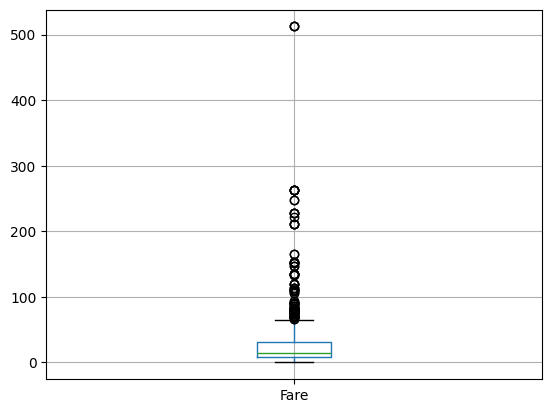

In [ ]:
# Puede observarse mediante un gráfico la distribución de los datos. ¿Qué información podemos extraer?¿Nos permite esta representación una división de los datos?
df.boxplot('Fare')

In [ ]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.202973
std,49.692923
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [ ]:
df['Fare-bin'] = pd.qcut(df.Fare,5,labels=[1,2,3,4,5]).astype(int)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Fare-bin
0,1,0,3,0,22.0,1,0,3,7.2500,2,5,1
1,2,1,1,1,38.0,1,0,5,71.2833,0,2,5
2,3,1,3,1,26.0,0,0,6,7.9250,2,3,2
3,4,1,1,1,35.0,1,0,0,52.0000,2,2,5
4,5,0,3,0,35.0,0,0,2,8.0500,2,5,2


**PassengerID**

In [ ]:
# ¿Nos indica algo?¿Podemos eliminarla?
df.drop('PassengerId', axis= 1, inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Fare-bin
0,0,3,0,22.0,1,0,3,7.2500,2,5,1
1,1,1,1,38.0,1,0,5,71.2833,0,2,5
2,1,3,1,26.0,0,0,6,7.9250,2,3,2
3,1,1,1,35.0,1,0,0,52.0000,2,2,5
4,0,3,0,35.0,0,0,2,8.0500,2,5,2


**EDAD**

In [ ]:
# ¿Tenemos valores nulos?
df['Age'].isna().value_counts()

,count
Age,
False,714
True,177


Otra manera de llenar los huecos no es solo haciendo la media sino empleando un algortimo por si mismo para poder predecir estos valores nulos.

In [ ]:
# Importamos la clase RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#¿Qué variables nos interesan para tener en cuenta?
df_sub = df[['Age','Title','Fare','SibSp']]

In [ ]:
#Para poder entrenar el modelo y comprobar que funciona adecuadamente para aplicarlo a los datos desconocidos debemos:
# 1. eliminar aquellas filas nulas de los datos de entrenamiento
# 2. guardar en test las filas nulas.
X_train  = df_sub.dropna().drop('Age', axis=1)
y_train  = df['Age'].dropna()

X_test = df_sub.loc[np.isnan(df.Age)].drop('Age', axis=1)

In [ ]:
# Aplicamos el algortimo
# Para ello creamos una instancia de RandomForestRegresor
regressor = RandomForestRegressor(n_estimators = 300)
# La función fit() nos permite entrenar el modelo, ajustados pesos dependiendo de los datos
regressor.fit(X_train, y_train)
# Una vez entrenado el modelo, este está listo para hacer predicciones, lo que se realiza mediante el método predict()
y_pred = np.round(regressor.predict(X_test),1)
y_pred

array([26.7, 31.5, 30.3, 33. , 22. , 28. , 32.1, 25.8, 24.9, 28. , 30.8,
       37. , 25.8, 25.1, 39.5, 36. ,  6.2, 28. , 30.8, 21.8, 30.8, 30.8,
       28. , 29.7,  4.9, 30.8, 41.7,  4.2, 31.4, 31. , 25.6,  8.9, 38.3,
       40.4,  6.5, 15.2, 30.6, 60.8, 31.2, 41.7, 25.8, 15.6, 28.2, 28. ,
        5.7, 21.3, 15.5,  8.5, 31. , 53.3, 41.7, 25.8, 43.3, 25.8, 34.4,
       40.3, 36. , 42.4, 25.8, 24.3, 21.5, 30.8, 29.6, 15.6,  4.6, 37.7,
       28. , 28.8, 59. , 33. , 22. , 22. , 37. , 30.3, 25.8, 41.9, 28. ,
       24.4,  5.7, 28. , 25. , 34.4, 30.3, 28. , 31. , 41.7, 28.8, 23.6,
       18.9, 30.8, 36. , 41.7, 30.8, 34.4, 24.4, 31. , 47. , 34.4,  5.7,
       18.9, 29.9, 30.6, 21.2, 48.4, 30.8, 37. , 33. , 24.9, 29. , 24.9,
       35.4, 30.2, 43.6, 27.3, 29. , 41.7, 30.8, 18.7, 24.9, 25.8, 25.4,
       25.6, 30.8, 25.8, 14.5, 33. , 28. , 37.4, 28. ,  8.5, 41.7, 24.4,
       34.4, 27.2, 29.7, 35.3, 28. , 23.6, 28. , 29.7, 35.8, 34.4, 18.7,
       29.7, 19.3,  6.2, 48.4, 33.1, 19.3, 34.4, 28

In [ ]:
# Sustituimos estos valores en el dataset
df.Age.loc[df.Age.isnull()] = y_pred

<ipython-input-535-8419d658c54e>:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.Age.loc[df.Age.isnull()] = y_pred
<ipython-input-535-8419d658c54e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

In [ ]:
# Comprobamos si nos quedan valores nulos o no
df.Age.isnull().sum(axis=0)

0

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Fare-bin
0,0,3,0,22.0,1,0,3,7.2500,2,5,1
1,1,1,1,38.0,1,0,5,71.2833,0,2,5
2,1,3,1,26.0,0,0,6,7.9250,2,3,2
3,1,1,1,35.0,1,0,0,52.0000,2,2,5
4,0,3,0,35.0,0,0,2,8.0500,2,5,2


Como se ha comentado anteriormente, tener muchas clases distintas no nos favorece necesariamente. Ante esta situación podemos hacer grupos para poder reducir el número de clases, por ejemplo por rango de edades.

In [ ]:
df['Age-bin'] = df['Age']
df.loc[df['Age-bin'] <= 16, 'Age-bin'] = 0
df.loc[(df['Age-bin'] > 16) & (df['Age-bin'] <= 32), 'Age-bin'] = 1
df.loc[(df['Age-bin'] > 32), 'Age-bin'] = 2

**Parch y Sibsp**

Un aspecto a añadir pueden ser los **dummies** en los cuales en lugar de tener una columna donde aparecen múltiples clases tenemos una columna con cada una de las clases indicando si el elemento de esa fila pertence a la clase '1' o no '0'.

In [ ]:
df['FamilySize'] = df['Parch'] + df['SibSp'] + 1
df['Singleton'] = df['FamilySize'].map(lambda s: 1 if s == 1 else 0)
df['SmallFamily'] = df['FamilySize'].map(lambda s: 1 if 2 <= s <= 3 else 0)
df['MediumFamily'] = df['FamilySize'].map(lambda s: 1 if s == 4 else 0)
df['LargeFamily'] = df['FamilySize'].map(lambda s: 1 if 5 <= s else 0)


### Ahora ya tenemos nuestra base de datos lista, por el momento....

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Fare-bin,Age-bin,FamilySize,Singleton,SmallFamily,MediumFamily,LargeFamily
0,0,3,0,22.0,1,0,3,7.2500,2,5,1,1.0,2,0,1,0,0
1,1,1,1,38.0,1,0,5,71.2833,0,2,5,2.0,2,0,1,0,0
2,1,3,1,26.0,0,0,6,7.9250,2,3,2,1.0,1,1,0,0,0
3,1,1,1,35.0,1,0,0,52.0000,2,2,5,2.0,2,0,1,0,0
4,0,3,0,35.0,0,0,2,8.0500,2,5,2,2.0,1,1,0,0,0


¿Cuáles son las variables que hemos de tratar para poder usar la base de datos?



In [ ]:
df.drop(labels=['Age'], axis=1, inplace=True)
df.drop(labels=['Parch'], axis=1, inplace=True)
df.drop(labels=['SibSp'], axis=1, inplace=True)
df.drop(labels=['Fare'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Ticket,Embarked,Title,Fare-bin,Age-bin,FamilySize,Singleton,SmallFamily,MediumFamily,LargeFamily
0,0,3,0,3,2,5,1,1.0,2,0,1,0,0
1,1,1,1,5,0,2,5,2.0,2,0,1,0,0
2,1,3,1,6,2,3,2,1.0,1,1,0,0,0
3,1,1,1,0,2,2,5,2.0,2,0,1,0,0
4,0,3,0,2,2,5,2,2.0,1,1,0,0,0
